In [7]:
!pip install seaborn matplotlib numpy pandas scikit-learn xgboost


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Telco_customer_churn.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [8]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

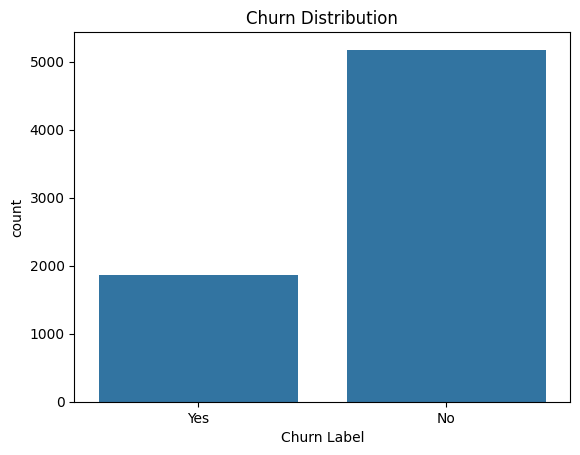

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn Label', data=df)
plt.title("Churn Distribution")
plt.show()

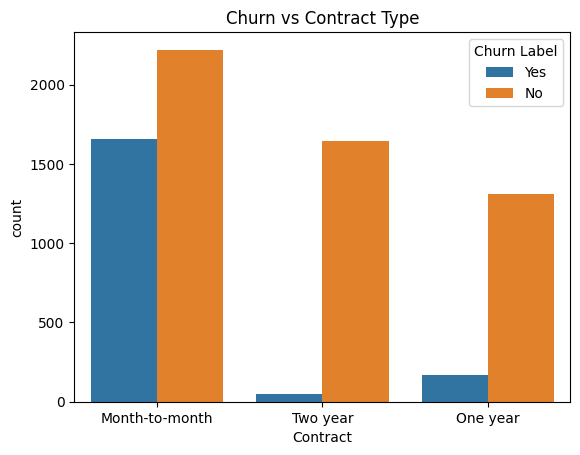

In [11]:
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.title("Churn vs Contract Type")
plt.show()

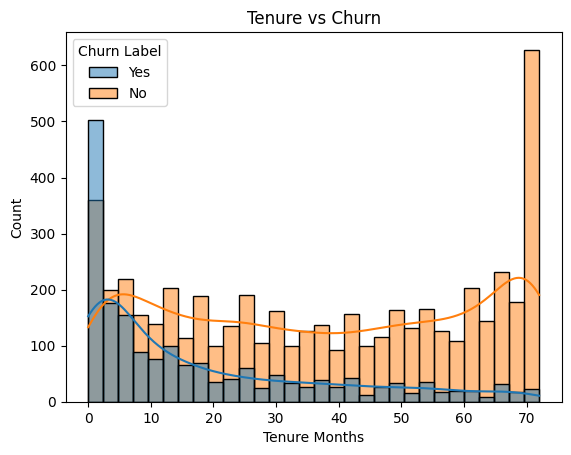

In [12]:
sns.histplot(data=df, x='Tenure Months', hue='Churn Label', bins=30, kde=True)
plt.title("Tenure vs Churn")
plt.show()

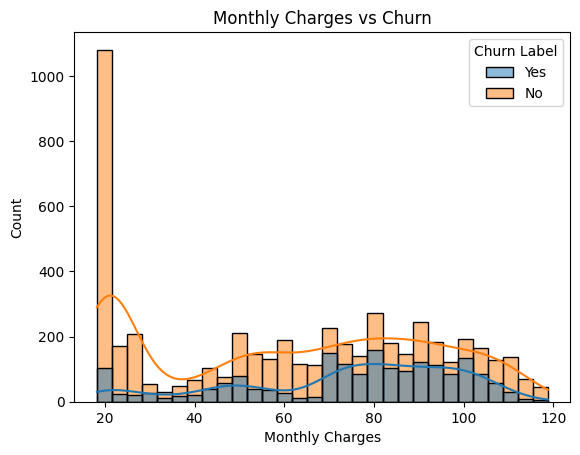

In [16]:
sns.histplot(data=df, x='Monthly Charges', hue='Churn Label', bins=30, kde=True)
plt.title("Monthly Charges vs Churn")
plt.show()

In [21]:
df = df.drop(['CustomerID', 'Churn Score', 'Churn Reason', 'Churn Value', 'CLTV'], axis=1, errors='ignore')

In [22]:
df.columns

Index(['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude',
       'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label'],
      dtype='str')

In [23]:
X = df.drop('Churn Label', axis=1)
y = df['Churn Label']

In [24]:
X.dtypes

Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges            str
dtype: object

In [26]:
X['Total Charges'] = pd.to_numeric(X['Total Charges'], errors='coerce')

In [27]:
X['Total Charges'].isnull().sum()

np.int64(11)

In [29]:
X['Total Charges'] = X['Total Charges'].fillna(X['Total Charges'].median())

In [30]:
X=X.drop(['Country','State','City','Zip Code','Lat Long'], axis=1)

In [32]:
X=pd.get_dummies(X)

In [34]:
X.shape

(7043, 49)

In [35]:
y=y.map({'Yes':1, 'No':0})

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
model= RandomForestClassifier()
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
y_pred=model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score

In [47]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7934705464868701


In [48]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[909 100]
 [191 209]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.68      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.78      0.79      0.78      1409



In [49]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [50]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[920  89]
 [198 202]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1009
           1       0.69      0.51      0.58       400

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [51]:
y_prob = model.predict_proba(X_test)[:,1]
y_pred_new = (y_prob > 0.3).astype(int)

In [52]:
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[784 225]
 [ 92 308]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1009
           1       0.58      0.77      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.78      1409



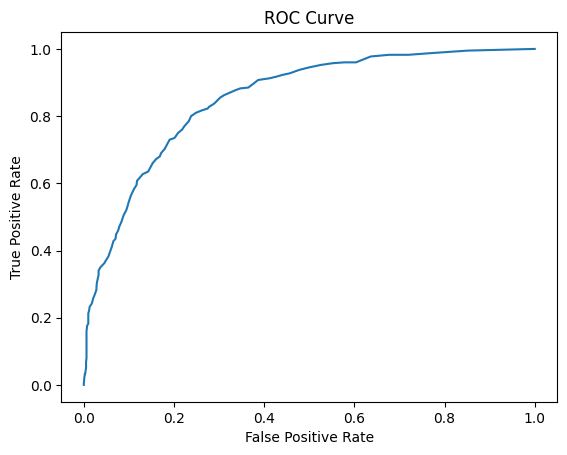

AUC: 0.8531987115956392


In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc_score(y_test, y_prob))

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Logistic Accuracy: 0.801277501774308
Decision Tree Accuracy: 0.7154009936124911
Gradient Boosting Accuracy: 0.8026969481902059


In [57]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

C:\Users\PRATHAMJIT SINGH\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:20:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1009
           1       0.61      0.51      0.56       400

    accuracy                           0.77      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.76      0.77      0.76      1409



In [58]:
y_prob = xgb_model.predict_proba(X_test)[:,1]

# Lower threshold to catch more churn
y_pred_new = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1009
           1       0.56      0.69      0.62       400

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.78      0.76      0.77      1409



                            Feature  Importance
40          Contract_Month-to-month    0.348312
20     Internet Service_Fiber optic    0.264994
42                Contract_Two year    0.052909
12                    Dependents_No    0.042800
22               Online Security_No    0.024237
41                Contract_One year    0.018916
31                  Tech Support_No    0.016288
3                     Tenure Months    0.014905
39             Streaming Movies_Yes    0.012756
47  Payment Method_Electronic check    0.012673


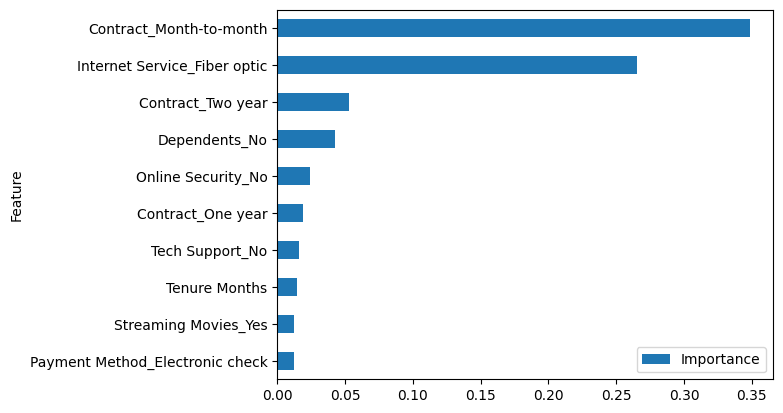

In [59]:

importance = xgb_model.feature_importances_
features = X.columns

df_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(df_imp.head(10))

# Plot
df_imp.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.gca().invert_yaxis()
plt.show()

In [60]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([0.80766501, 0.81689141, 0.80198722, 0.80823864, 0.80681818])

In [61]:
print(type(model))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [63]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

# define RF properly
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

models = {
    "Random Forest": rf_model,
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier()
}

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Random Forest
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1009
           1       0.70      0.51      0.59       400

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Gradient Boosting
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1009
           1       0.69      0.55      0.61       400

    accuracy                           0.80      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.79      0.80      0.79      1409


Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.57      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       

In [64]:
for name, m in models.items():
    m.fit(X_train, y_train)

    y_prob = m.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.3).astype(int)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Random Forest
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1009
           1       0.57      0.78      0.66       400

    accuracy                           0.77      1409
   macro avg       0.74      0.77      0.74      1409
weighted avg       0.80      0.77      0.78      1409


Gradient Boosting
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1009
           1       0.58      0.78      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.81      0.78      0.79      1409


Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1009
           1       0.56      0.76      0.65       400

    accuracy                           0.76      1409
   macro avg       0.73      0.76      0.73      1409
weighted avg       

In [65]:
import joblib

joblib.dump(rf_model, "churn_model.pkl")

['churn_model.pkl']

In [66]:
threshold = 0.3
joblib.dump(threshold, "threshold.pkl")

['threshold.pkl']

In [69]:
model = joblib.load("churn_model.pkl")
threshold = joblib.load("threshold.pkl")

X_new = X_test[:5]   # FIXED

y_prob = model.predict_proba(X_new)[:,1]
y_pred = (y_prob > threshold).astype(int)

print(y_pred)

[1 0 0 1 1]


In [70]:
print("Probabilities:", y_prob)
print("Predictions:", y_pred)

Probabilities: [0.31 0.19 0.13 0.64 0.31]
Predictions: [1 0 0 1 1]


In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.89      0.80      0.85      1009
           1       0.60      0.75      0.67       400

    accuracy                           0.79      1409
   macro avg       0.75      0.78      0.76      1409
weighted avg       0.81      0.79      0.80      1409



In [72]:
import joblib
joblib.dump(best_model, "churn_model.pkl")

['churn_model.pkl']

In [73]:
threshold = 0.3
joblib.dump(threshold, "threshold.pkl")

['threshold.pkl']

In [74]:
joblib.dump(best_model, "churn_model.pkl")
joblib.dump(threshold, "threshold.pkl")

['threshold.pkl']